# PNMR analysis walkthrough

This notebook reproduces the two main quantitative analyses in the pulsed-NMR experiment:

1. **`T1` from inversion recovery**
2. **`T2` from a Meiboom–Gill echo train (`DS0001A.CSV`)**

The same code path is used by the package in `src/pnmr_showcase`, so the notebook doubles as a readable narrative and a reproducible analysis record.


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve().parents[0]
sys.path.insert(0, str(ROOT / "src"))

import pandas as pd
from pnmr_showcase.io import read_scope_csv, load_t1_dataset, load_zero_crossing_metadata
from pnmr_showcase.t1 import propagate_t1_from_zero_crossing, fit_t1_inversion_recovery
from pnmr_showcase.t2 import estimate_baseline, extract_echo_peaks, fit_t2_envelope
from pnmr_showcase.plotting import plot_t1_fit, plot_t2_fit, plot_waveform_with_peaks

DATA = ROOT / "data" / "raw"
FIGURES = ROOT / "figures"
FIGURES.mkdir(exist_ok=True)


## 1. `T1` from inversion recovery

In [2]:
t1_df = load_t1_dataset(DATA / "t1_inversion_recovery.csv")
zero_meta = load_zero_crossing_metadata(DATA / "t1_zero_crossing.json")

t1_zero = propagate_t1_from_zero_crossing(**zero_meta)
t1_fit = fit_t1_inversion_recovery(
    t1_df["delay_ms"].to_numpy(),
    t1_df["amplitude_mV"].to_numpy(),
    t1_df["sigma_amplitude_mV"].to_numpy(),
)

summary_t1 = pd.DataFrame(
    {
        "method": ["zero crossing", "weighted nonlinear fit"],
        "value_ms": [t1_zero.t1_ms, t1_fit.t1_ms],
        "sigma_ms": [t1_zero.sigma_t1_ms, t1_fit.sigma_t1_ms],
    }
)
summary_t1


,method,value_ms,sigma_ms
0,zero crossing,51.215674,3.606738
1,weighted nonlinear fit,52.098630,1.078665


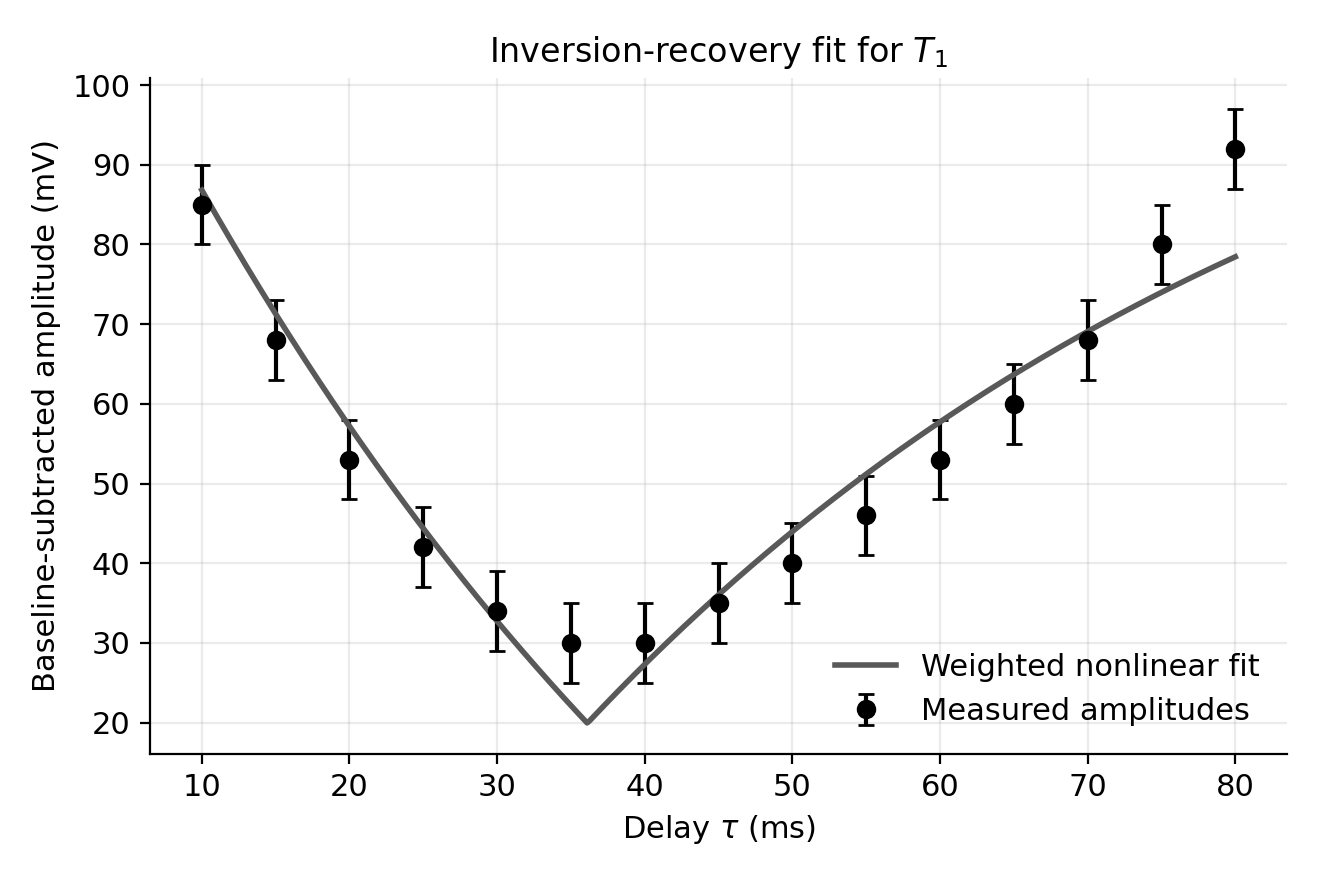

In [3]:
plot_t1_fit(
    t1_df["delay_ms"].to_numpy(),
    t1_df["amplitude_mV"].to_numpy(),
    t1_df["sigma_amplitude_mV"].to_numpy(),
    (t1_fit.offset_mV, t1_fit.amplitude_mV, t1_fit.t1_ms),
    FIGURES / "t1_fit.png",
)
from IPython.display import Image
Image(filename=str(FIGURES / "t1_fit.png"))


## 2. `T2` from the Meiboom–Gill waveform export

In [4]:
waveform = read_scope_csv(DATA / "DS0001A.CSV")
baseline = estimate_baseline(waveform)
peaks = extract_echo_peaks(waveform, baseline=baseline)
t2_fit = fit_t2_envelope(peaks.time_ms, peaks.amplitude_mV, peaks.sigma_amplitude_mV)

summary_t2 = pd.DataFrame(
    {
        "quantity": ["baseline mean (mV)", "baseline RMS noise (mV)", "detected echo peaks", "T2 fit (ms)", "sigma_T2 (ms)"],
        "value": [peaks.baseline_mV, peaks.baseline_rms_mV, len(peaks.time_ms), t2_fit.t2_ms, t2_fit.sigma_t2_ms],
    }
)
summary_t2


,quantity,value
0,baseline mean (mV),118.099571
1,baseline RMS noise (mV),0.890988
2,detected echo peaks,36.000000
3,T2 fit (ms),44.544929
4,sigma_T2 (ms),1.052137


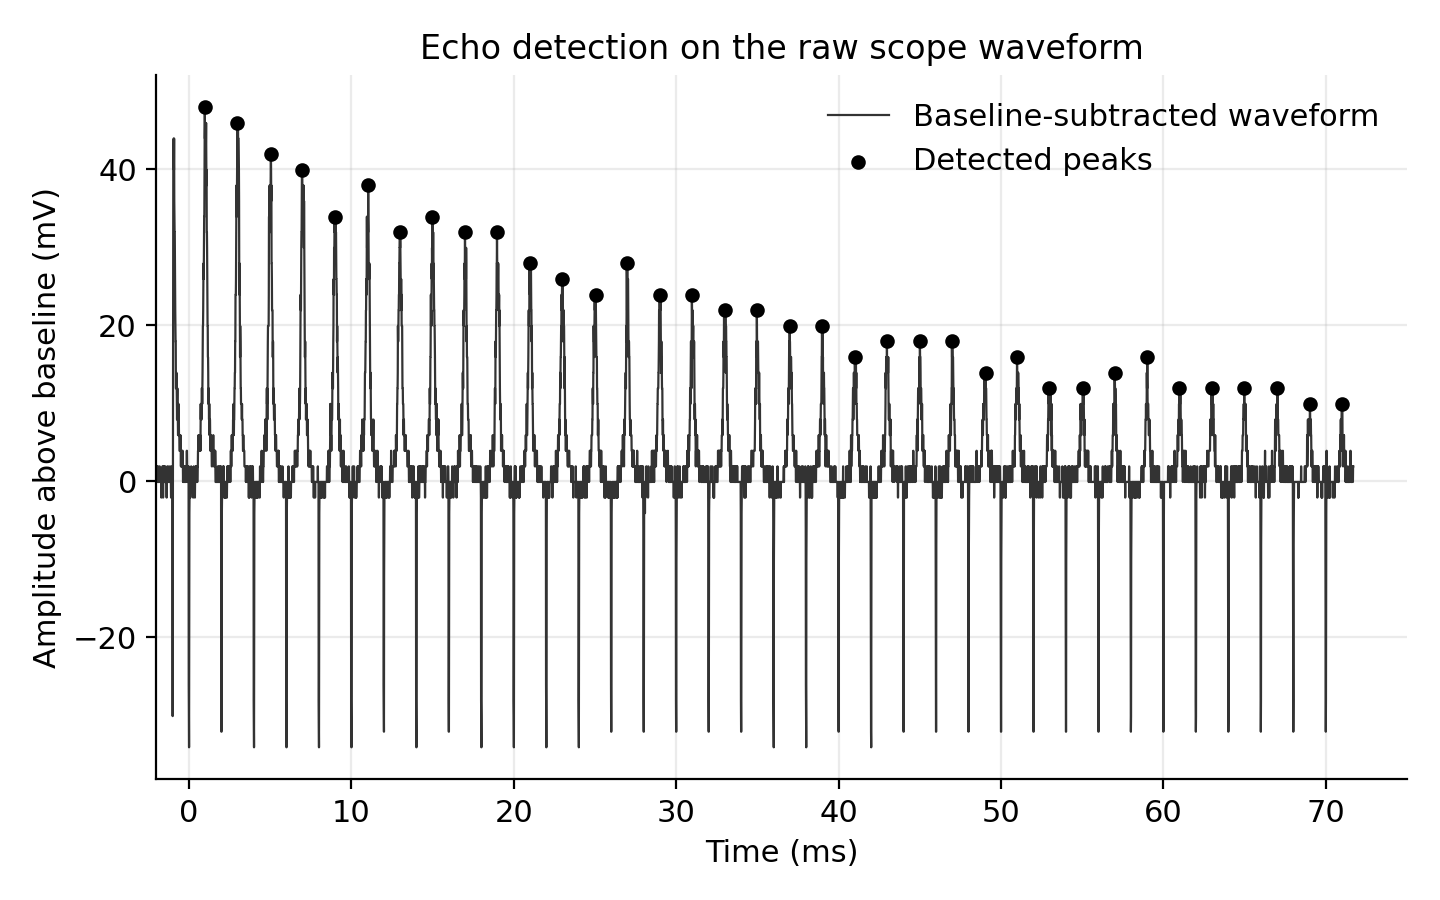

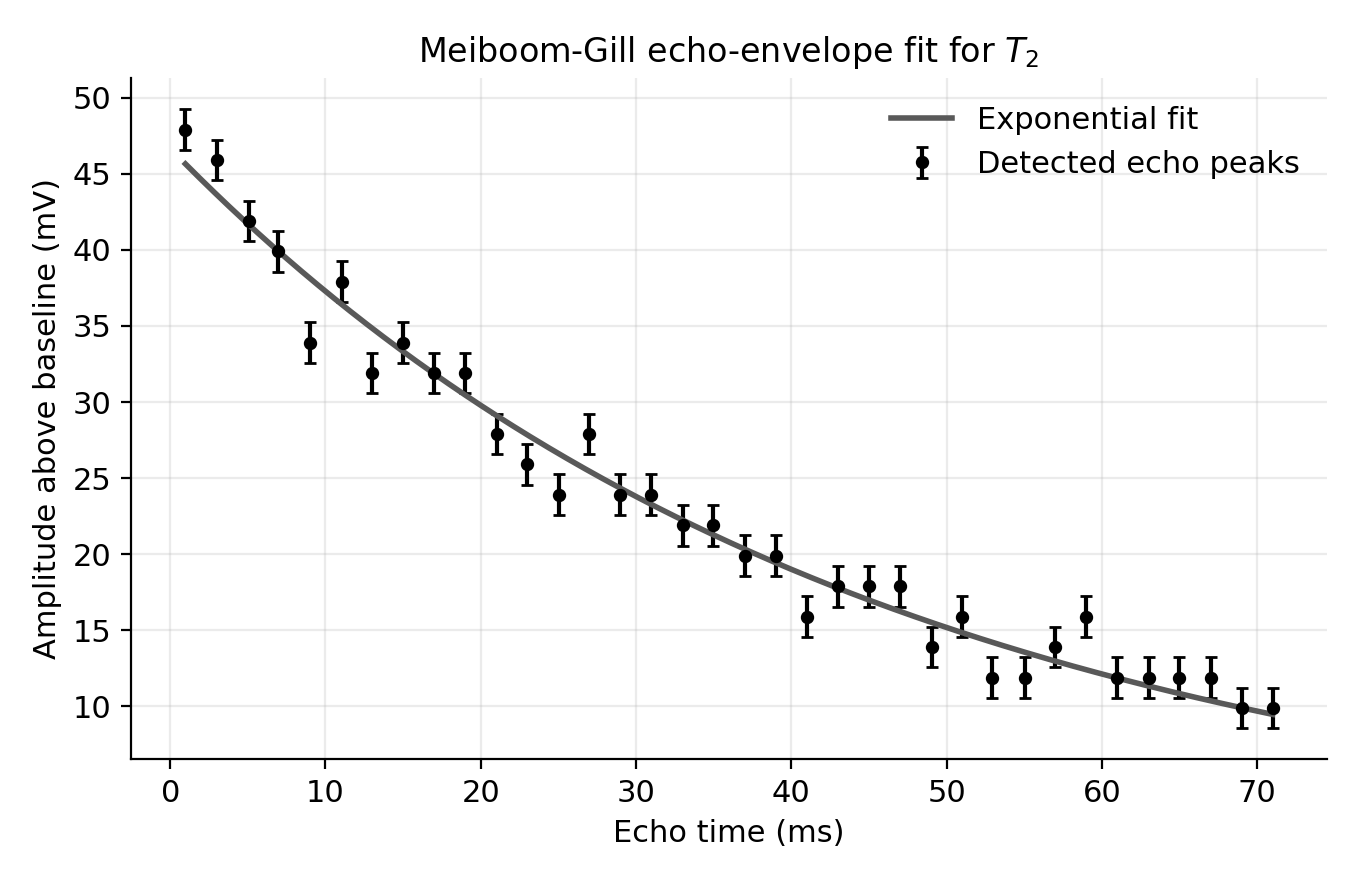

In [5]:
plot_waveform_with_peaks(
    waveform.time_ms,
    (waveform.voltage_v - baseline.mean_v) * 1e3,
    peaks.time_ms,
    peaks.amplitude_mV,
    FIGURES / "t2_waveform_with_peaks.png",
)
plot_t2_fit(
    peaks.time_ms,
    peaks.amplitude_mV,
    peaks.sigma_amplitude_mV,
    (t2_fit.amplitude_mV, t2_fit.t2_ms),
    FIGURES / "t2_fit.png",
)

from IPython.display import display, Image
display(Image(filename=str(FIGURES / "t2_waveform_with_peaks.png")))
display(Image(filename=str(FIGURES / "t2_fit.png")))


## 3. Portfolio-style summary table

In [6]:
portfolio_summary = pd.DataFrame(
    {
        "analysis block": ["Part A cursor check", "T1 zero crossing", "T1 nonlinear fit", "T2 CSV fit"],
        "core result": [
            r"Single pulse: 35.1 ± 1.0 μs; two-pulse separation: 78.2 ± 1.0 μs",
            f"{t1_zero.t1_ms:.2f} ± {t1_zero.sigma_t1_ms:.2f} ms",
            f"{t1_fit.t1_ms:.2f} ± {t1_fit.sigma_t1_ms:.2f} ms",
            f"{t2_fit.t2_ms:.2f} ± {t2_fit.sigma_t2_ms:.2f} ms",
        ],
        "skill demonstrated": [
            "instrument readout interpretation",
            "uncertainty propagation",
            "weighted nonlinear least squares",
            "signal processing + peak finding + exponential fitting",
        ],
    }
)
portfolio_summary


,analysis block,core result,skill demonstrated
0,Part A cursor check,Single pulse: 35.1 ± 1.0 μs; two-pulse separat...,instrument readout interpretation
1,T1 zero crossing,51.22 ± 3.61 ms,uncertainty propagation
2,T1 nonlinear fit,52.10 ± 1.08 ms,weighted nonlinear least squares
3,T2 CSV fit,44.54 ± 1.05 ms,signal processing + peak finding + exponential...
